<a href="https://colab.research.google.com/github/ansmalik67/nanSense-ds-hack/blob/ans_branch/nansense_ds_hack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Colab: Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split

In [6]:
train_df = pd.read_csv('/content/drive/MyDrive/dataset/dataset_B_training.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/dataset/dataset_B_testing.csv')

print(f'Training shape : {train_df.shape}')
print(f'Testing  shape : {test_df.shape}')
train_df.head()

Training shape : (4756, 31)
Testing  shape : (4749, 30)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,h1n1_vaccine
0,1,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",2.0,1.0,science,0
1,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,Below Poverty,Not Married,Own,Employed,Non-MSA,0.0,3.0,wholesale,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"> $75,000",Not Married,Own,Employed,"MSA, Principle City",0.0,0.0,education,1
3,4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Female,"<= $75,000, Above Poverty",Not Married,Rent,Not in Labor Force,Non-MSA,0.0,0.0,NaN,0
4,5,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Female,NaN,Not Married,NaN,Unemployed,Non-MSA,3.0,0.0,NaN,0


In [20]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   h1n1_concern                 4741 non-null   float64
 2   h1n1_knowledge               4734 non-null   float64
 3   behavioral_antiviral_meds    4739 non-null   float64
 4   behavioral_avoidance         4729 non-null   float64
 5   behavioral_face_mask         4752 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4741 non-null   float64
 9   behavioral_touch_face        4736 non-null   float64
 10  doctor_recc_h1n1             4437 non-null   float64
 11  chronic_med_condition        4595 non-null   float64
 12  child_under_6_months         4622 non-null   float64
 13  health_worker     

In [22]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
respondent_id,4756.0,2378.500000,1373.083270,1.0,1189.75,2378.5,3567.25,4756.0
h1n1_concern,4741.0,1.658933,0.892478,0.0,1.00,2.0,2.00,3.0
h1n1_knowledge,4734.0,1.307140,0.612811,0.0,1.00,1.0,2.00,2.0
behavioral_antiviral_meds,4739.0,0.057396,0.232622,0.0,0.00,0.0,0.00,1.0
behavioral_avoidance,4729.0,0.740960,0.438154,0.0,0.00,1.0,1.00,1.0
behavioral_face_mask,4752.0,0.077652,0.267651,0.0,0.00,0.0,0.00,1.0
behavioral_wash_hands,4748.0,0.842039,0.364743,0.0,1.00,1.0,1.00,1.0
behavioral_large_gatherings,4747.0,0.359385,0.479871,0.0,0.00,0.0,1.00,1.0
behavioral_outside_home,4741.0,0.341278,0.474189,0.0,0.00,0.0,1.00,1.0
behavioral_touch_face,4736.0,0.704814,0.456174,0.0,0.00,1.0,1.00,1.0


In [9]:
train_df.isnull().sum()

,0
respondent_id,0
h1n1_concern,15
h1n1_knowledge,22
behavioral_antiviral_meds,17
behavioral_avoidance,27
behavioral_face_mask,4
behavioral_wash_hands,8
behavioral_large_gatherings,9
behavioral_outside_home,15
behavioral_touch_face,20


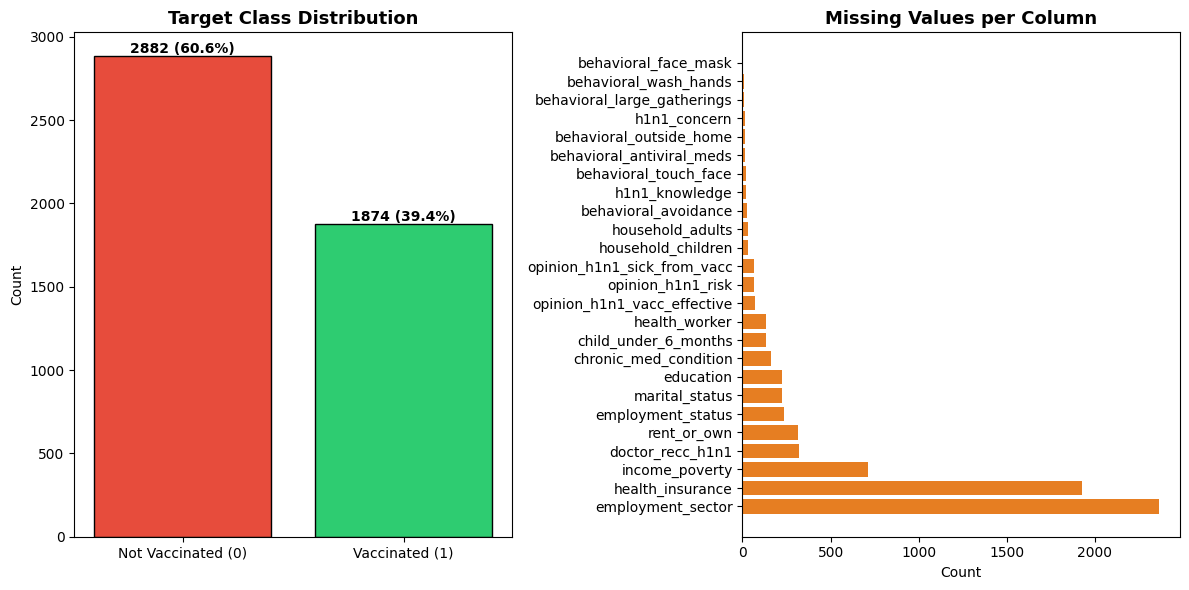

Figure saved: eda_overview.png


In [18]:
# --- Target distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

counts = train_df['h1n1_vaccine'].value_counts()
axes[0].bar(['Not Vaccinated (0)', 'Vaccinated (1)'], counts, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v + 20, f'{v} ({v/len(train_df)*100:.1f}%)', ha='center', fontweight='bold')

# --- Missing values heatmap ---
missing = train_df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
axes[1].barh(missing.index, missing.values, color='#e67e22')
axes[1].set_title('Missing Values per Column', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: eda_overview.png')

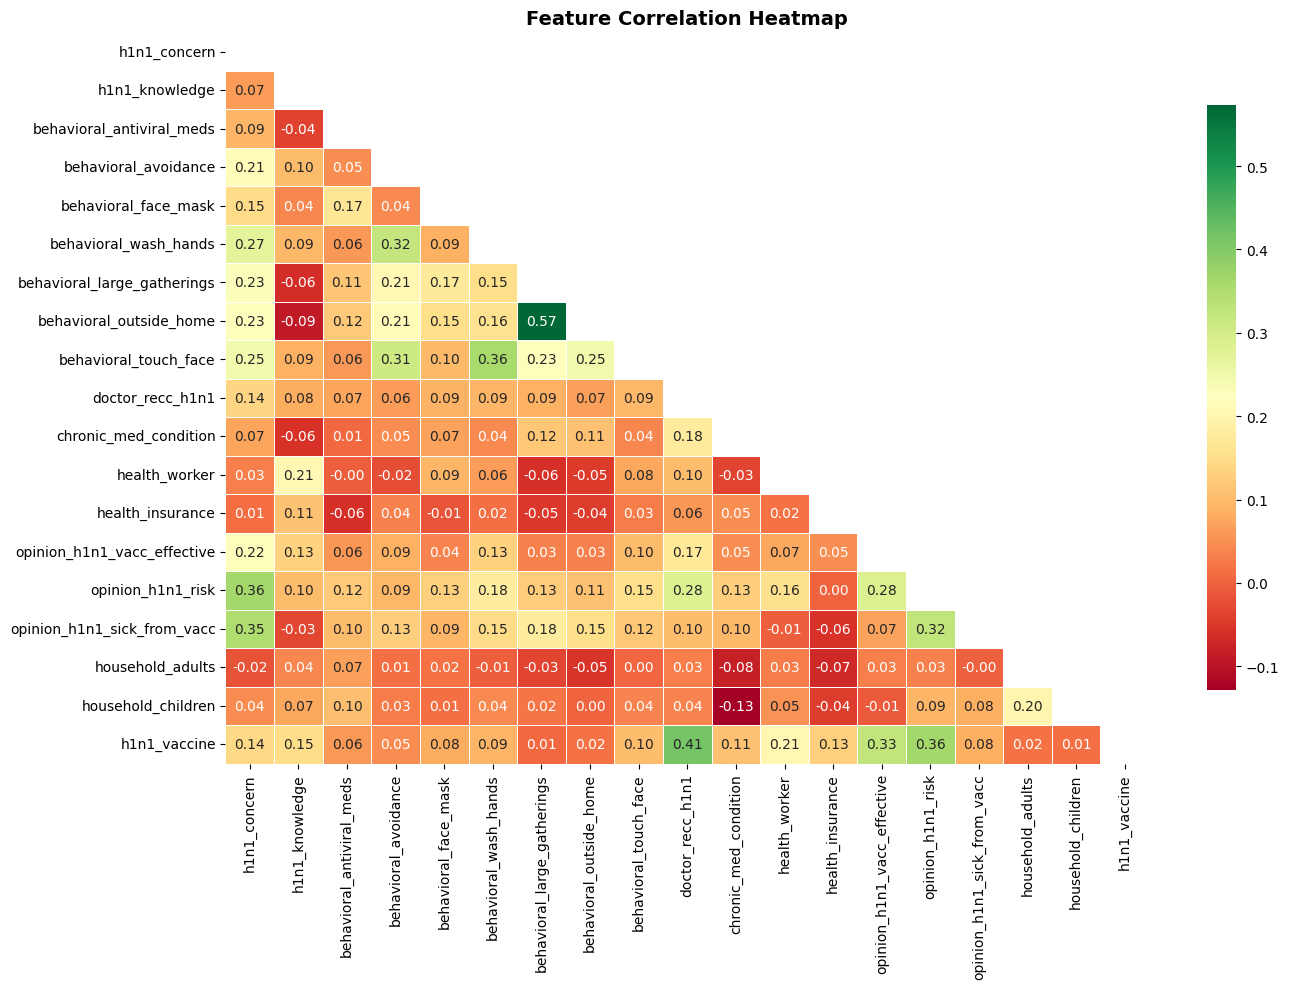

Figure saved: correlation_heatmap.png


In [19]:
# --- Correlation heatmap (numeric features) ---
num_cols = [
    'h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
    'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
    'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face',
    'doctor_recc_h1n1', 'chronic_med_condition', 'health_worker', 'health_insurance',
    'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc',
    'household_adults', 'household_children', 'h1n1_vaccine'
]

plt.figure(figsize=(14, 10))
corr = train_df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: correlation_heatmap.png')

In [ ]:
X = train_df.drop('h1n1_vaccine', axis=1)
y = train_df['h1n1_vaccine']

In [25]:
# Split a Pandas DataFrame or Numpy Array into Train and Test sets
train_set, test_set = train_test_split(train_df, test_size=0.2, random_state=42)

# If your features (X) and target (y) are separated:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


NameError: name 'X' is not defined